In [1]:
import numpy as np
import scanpy as sc
from scipy.sparse import issparse

# -----------------------------
# Config
# -----------------------------
PATH = "/work3/s252608/DL_project/data/processed/bulk_normalized_x_input.h5ad"
BATCH_SIZE = 512

# -----------------------------
# Open in backed mode (low RAM)
# -----------------------------
adata = sc.read_h5ad(PATH, backed="r")

n_obs, n_vars = adata.shape
print(f"Shape: {n_obs:,} samples × {n_vars:,} genes")

# -----------------------------
# Streaming variance computation
# Welford online algorithm
# -----------------------------
mean = np.zeros(n_vars, dtype=np.float64)
M2 = np.zeros(n_vars, dtype=np.float64)
count = 0

for start in range(0, n_obs, BATCH_SIZE):
    end = min(start + BATCH_SIZE, n_obs)

    X_batch = adata.X[start:end]

    if issparse(X_batch):
        X_batch = X_batch.toarray()

    X_batch = np.asarray(X_batch, dtype=np.float64)

    for x in X_batch:
        count += 1
        delta = x - mean
        mean += delta / count
        delta2 = x - mean
        M2 += delta * delta2

    print(f"{end:,}/{n_obs:,}", end="\r")

variance = M2 / (count - 1)
std = np.sqrt(variance)

print("\nDone.")

# -----------------------------
# Summary statistics
# -----------------------------
print("\nVariance summary:")
print(f"Mean variance:   {variance.mean():.4f}")
print(f"Median variance: {np.median(variance):.4f}")
print(f"Min variance:    {variance.min():.4f}")
print(f"Max variance:    {variance.max():.4f}")

print("\nStd summary:")
print(f"Mean std:        {std.mean():.4f}")
print(f"Median std:      {np.median(std):.4f}")

Shape: 19,882 samples × 2,204 genes
19,882/19,882
Done.

Variance summary:
Mean variance:   0.2720
Median variance: 0.1987
Min variance:    0.0004
Max variance:    4.1202

Std summary:
Mean std:        0.4743
Median std:      0.4458


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

QC_PATH = Path("/work3/s252608/DL_project/data/qc/bulk_processed_qc_relaxed_labels.csv")
OUT_DIR = Path("/work3/s252608/DL_project/results/qc_figures")
OUT_DIR.mkdir(parents=True, exist_ok=True)

qc = pd.read_csv(QC_PATH)

# -----------------------------
# Dataset-level numbers
# -----------------------------
INITIAL_GENES = 45263
F1_RETAINED = len(qc)
F1_REMOVED = INITIAL_GENES - F1_RETAINED

print("Initial genes:", INITIAL_GENES)
print("After F1 genes:", F1_RETAINED)
print("Removed at F1:", F1_REMOVED)


# -----------------------------
# Sequential attrition table
# -----------------------------
def attrition_from_fail_reason(df, pass_col, fail_col, label):
    total_after_f1 = len(df)
    rows = []

    rows.append({
        "setting": label,
        "filter": "Initial genes",
        "retained": INITIAL_GENES,
        "removed_at_filter": 0,
    })

    rows.append({
        "setting": label,
        "filter": "F1: >=2 isoforms",
        "retained": total_after_f1,
        "removed_at_filter": F1_REMOVED,
    })

    current = total_after_f1

    filter_order = [
        ("F2_n_both_detected", "F2: >=50 both-detected samples"),
        ("F3_median_ratio", "F3: median(sumTx/gene) <= 1.5"),
        ("F4_corr", "F4: corr(gene, sumTx) threshold"),
        ("F5_low_active", "F5: >=20 active samples"),
        ("F5_dominant", "F6: mean dominant isoform <= 0.9"),
    ]

    for reason, pretty in filter_order:
        removed = int((df[fail_col] == reason).sum())
        current -= removed
        rows.append({
            "setting": label,
            "filter": pretty,
            "retained": current,
            "removed_at_filter": removed,
        })

    rows.append({
        "setting": label,
        "filter": "Final passed QC",
        "retained": int(df[pass_col].sum()),
        "removed_at_filter": 0,
    })

    return pd.DataFrame(rows)


strict_attrition = attrition_from_fail_reason(
    qc,
    pass_col="qc_pass",
    fail_col="fail_reason",
    label="strict_corr_0.8",
)

relaxed_attrition = attrition_from_fail_reason(
    qc,
    pass_col="qc_pass_relaxed",
    fail_col="fail_reason_relaxed",
    label="relaxed_corr_0.6",
)

attrition = pd.concat([strict_attrition, relaxed_attrition], ignore_index=True)

display(attrition)

attrition.to_csv(OUT_DIR / "qc_filter_attrition_table.csv", index=False)
print("Saved:", OUT_DIR / "qc_filter_attrition_table.csv")

Initial genes: 45263
After F1 genes: 19951
Removed at F1: 25312


,setting,filter,retained,removed_at_filter
0,strict_corr_0.8,Initial genes,45263,0
1,strict_corr_0.8,F1: >=2 isoforms,19951,25312
2,strict_corr_0.8,F2: >=50 both-detected samples,19951,0
3,strict_corr_0.8,F3: median(sumTx/gene) <= 1.5,11264,8687
4,strict_corr_0.8,"F4: corr(gene, sumTx) threshold",1385,9879
5,strict_corr_0.8,F5: >=20 active samples,1385,0
6,strict_corr_0.8,F6: mean dominant isoform <= 0.9,1279,106
7,strict_corr_0.8,Final passed QC,1279,0
8,relaxed_corr_0.6,Initial genes,45263,0
9,relaxed_corr_0.6,F1: >=2 isoforms,19951,25312


Saved: /work3/s252608/DL_project/results/qc_figures/qc_filter_attrition_table.csv


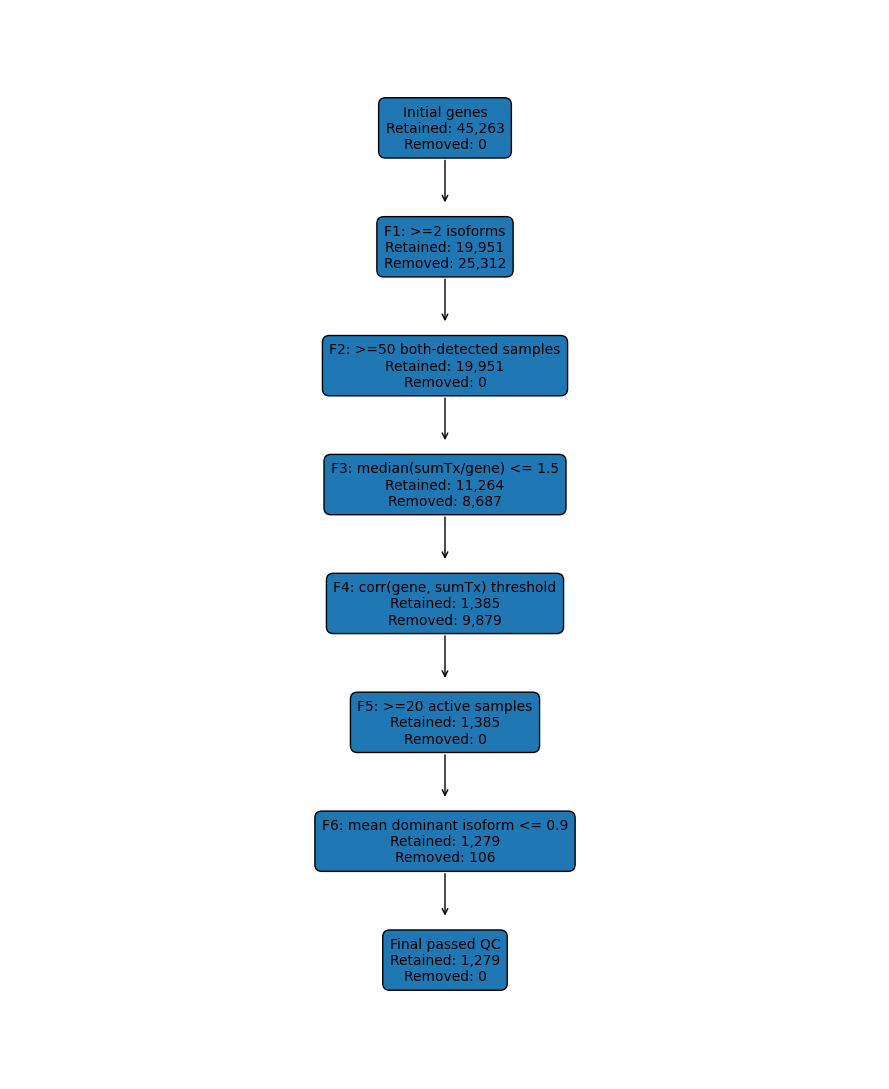

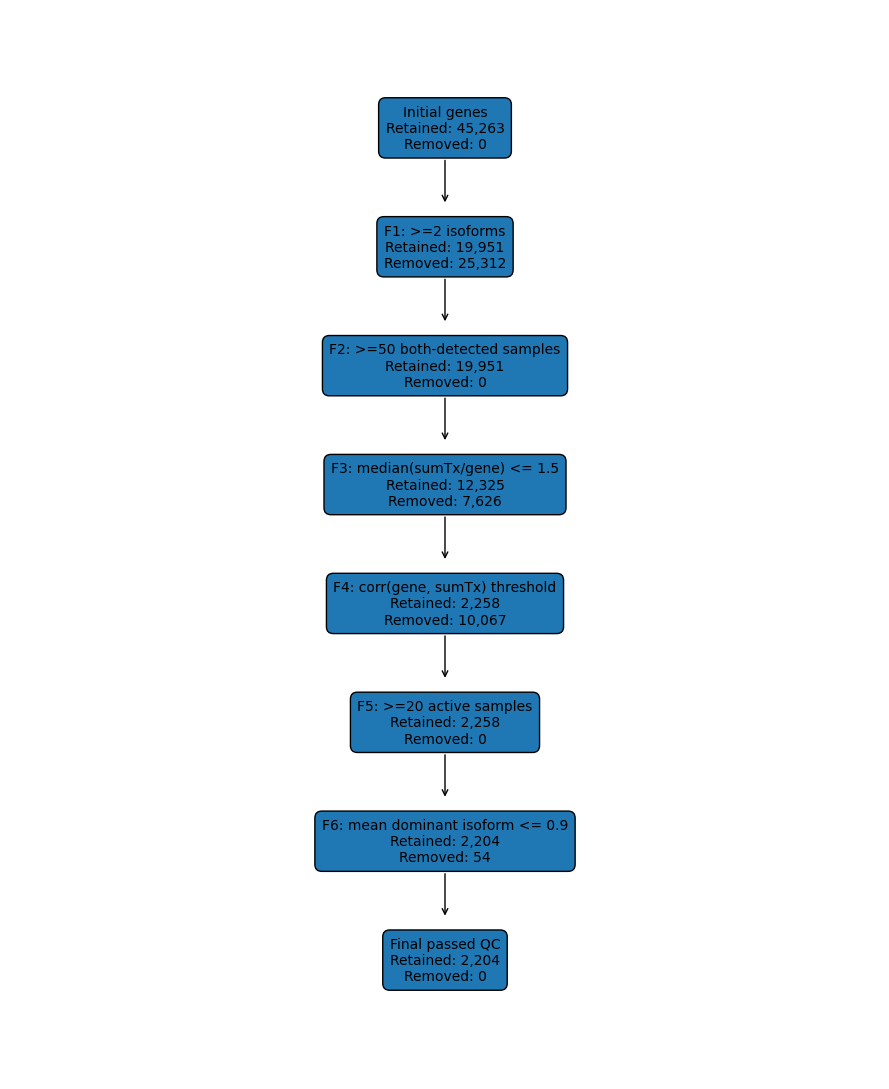

In [3]:
# -----------------------------
# Decision-tree style QC figure
# -----------------------------
def plot_qc_tree(attrition_df, setting, output_path):
    df = attrition_df[attrition_df["setting"] == setting].copy()

    labels = []
    for _, row in df.iterrows():
        labels.append(
            f"{row['filter']}\n"
            f"Retained: {row['retained']:,}\n"
            f"Removed: {row['removed_at_filter']:,}"
        )

    fig, ax = plt.subplots(figsize=(9, 11))
    ax.axis("off")

    y_positions = list(reversed(range(len(labels))))

    for i, (label, y) in enumerate(zip(labels, y_positions)):
        ax.text(
            0.5, y,
            label,
            ha="center",
            va="center",
            bbox=dict(boxstyle="round,pad=0.5", linewidth=1),
            fontsize=10,
        )

        if i < len(labels) - 1:
            ax.annotate(
                "",
                xy=(0.5, y - 0.65),
                xytext=(0.5, y - 0.25),
                arrowprops=dict(arrowstyle="->", linewidth=1),
            )

    ax.set_ylim(-1, len(labels))
    ax.set_xlim(0, 1)

    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()

plot_qc_tree(
    attrition,
    setting="strict_corr_0.8",
    output_path=OUT_DIR / "qc_decision_tree_strict_corr08.png",
)

plot_qc_tree(
    attrition,
    setting="relaxed_corr_0.6",
    output_path=OUT_DIR / "qc_decision_tree_relaxed_corr06.png",
)

In [4]:
# -----------------------------
# Candidate good genes for dataset figure
# -----------------------------
good = qc[
    (qc["qc_pass_relaxed"] == True)
    & (qc["corr_gene_vs_sum_iso"] >= 0.9)
    & (qc["median_ratio_sumTx_to_gene"].between(0.75, 1.25))
    & (qc["mean_dominant_fraction"] <= 0.6)
    & (qc["mean_entropy"] >= 0.4)
].copy()

good = good.sort_values(
    by=["corr_gene_vs_sum_iso", "mean_entropy"],
    ascending=[False, False]
)

cols = [
    "gene_id",
    "n_isoforms",
    "corr_gene_vs_sum_iso",
    "median_ratio_sumTx_to_gene",
    "mean_dominant_fraction",
    "mean_entropy",
    "n_both_detected",
]

display(good[cols].head(20))

,gene_id,n_isoforms,corr_gene_vs_sum_iso,median_ratio_sumTx_to_gene,mean_dominant_fraction,mean_entropy,n_both_detected
1013,ATAD3B,6,1.000000,1.000000,0.453891,0.763354,19853
1170,SLC35E2A,4,1.000000,1.000000,0.517594,0.750822,19822
1167,LINC01770,4,1.000000,1.000000,0.522965,0.705082,11796
1092,C1QTNF12,5,1.000000,1.000000,0.498640,0.695430,18394
832,ZBTB48,8,1.000000,1.000000,0.460980,0.692732,19806
1165,HES4,4,1.000000,1.000000,0.545272,0.691472,18252
1020,LNCTAM34A,6,1.000000,1.000000,0.542146,0.603002,16452
759,FBXO44,9,1.000000,1.000000,0.484936,0.595000,19823
1019,LINC01134,6,1.000000,1.000000,0.526645,0.589643,19448
607,ENSG00000217801,11,1.000000,1.000000,0.430496,0.582298,19611


Selected gene: ATAD3B
Number of isoforms: 6
Transcript IDs: ['ENST00000673477', 'ENST00000308647', 'ENST00000472194', 'ENST00000378736', 'ENST00000485748', 'ENST00000474481']
Samples: 19882
Informative samples: 19853
Correlation: 1.0


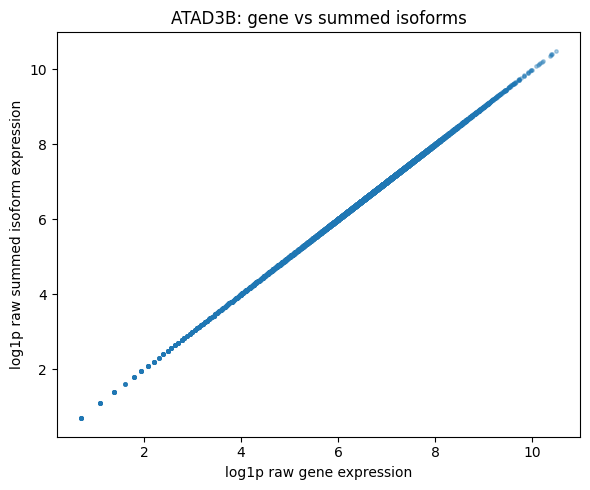

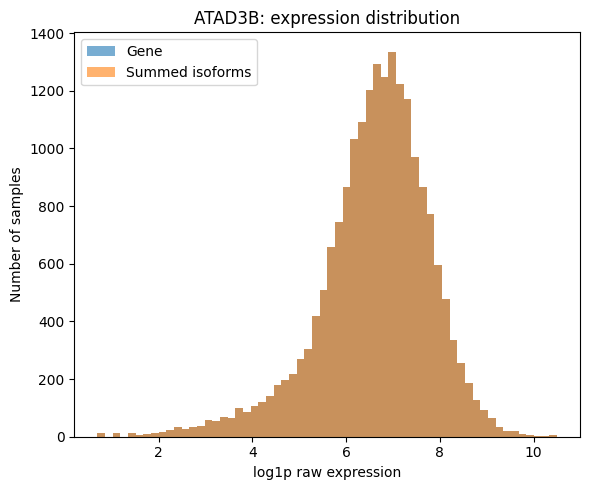

In [8]:
import json
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt
from scipy.sparse import issparse
from pathlib import Path

# -----------------------------
# Paths
# -----------------------------
RAW_GENE = "/work3/s252608/DL_project/data/raw/bulk_processed_genes.h5ad"
RAW_TX = "/work3/s252608/DL_project/data/raw/bulk_processed_transcripts.h5ad"
MAPPING = "/work3/s252608/DL_project/data/raw/bulk_processed_gene_to_transcripts.json"

OUT_DIR = Path("/work3/s252608/DL_project/results/qc_figures")
OUT_DIR.mkdir(parents=True, exist_ok=True)

ROW_BLOCK_SIZE = 256

# -----------------------------
# Select one readable good gene
# Requires `good` dataframe from previous filtering
# -----------------------------
readable_good = good[good["n_isoforms"].between(3, 8)].copy()

if readable_good.empty:
    raise ValueError("No good gene with 3–8 isoforms found. Relax the n_isoforms filter.")

GENE_ID = readable_good.iloc[0]["gene_id"]

# -----------------------------
# Load backed AnnData
# -----------------------------
adata_gene = sc.read_h5ad(RAW_GENE, backed="r")
adata_tx = sc.read_h5ad(RAW_TX, backed="r")

with open(MAPPING, "r") as f:
    gene_to_tx = json.load(f)

tx_ids = [tx for tx in gene_to_tx[GENE_ID] if tx in adata_tx.var_names]

gene_idx = adata_gene.var_names.get_loc(GENE_ID)
tx_idx = [adata_tx.var_names.get_loc(tx) for tx in tx_ids]

print("Selected gene:", GENE_ID)
print("Number of isoforms:", len(tx_idx))
print("Transcript IDs:", tx_ids)

# -----------------------------
# Read one transcript at a time
# Low RAM, avoids bad sparse backed slicing
# -----------------------------
g_list = []
sum_tx_list = []

for start in range(0, adata_gene.n_obs, ROW_BLOCK_SIZE):
    end = min(start + ROW_BLOCK_SIZE, adata_gene.n_obs)

    g_block = adata_gene[start:end, gene_idx].X
    if issparse(g_block):
        g_block = g_block.toarray()
    g_block = np.asarray(g_block).reshape(-1).astype(np.float32)

    sum_tx_block = np.zeros(end - start, dtype=np.float32)

    for tx_col in tx_idx:
        tx_block = adata_tx[start:end, tx_col].X
        if issparse(tx_block):
            tx_block = tx_block.toarray()
        tx_block = np.asarray(tx_block).reshape(-1).astype(np.float32)

        sum_tx_block += tx_block

    g_list.append(g_block)
    sum_tx_list.append(sum_tx_block)

g = np.concatenate(g_list)
sum_tx = np.concatenate(sum_tx_list)

mask = (g > 0) | (sum_tx > 0)

print("Samples:", len(g))
print("Informative samples:", mask.sum())
print("Correlation:", np.corrcoef(g[mask], sum_tx[mask])[0, 1])

# -----------------------------
# Scatter plot
# -----------------------------
plt.figure(figsize=(6, 5))
plt.scatter(
    np.log1p(g[mask]),
    np.log1p(sum_tx[mask]),
    s=6,
    alpha=0.35,
)
plt.xlabel("log1p raw gene expression")
plt.ylabel("log1p raw summed isoform expression")
plt.title(f"{GENE_ID}: gene vs summed isoforms")
plt.tight_layout()
plt.savefig(OUT_DIR / f"{GENE_ID}_raw_gene_vs_sum_isoforms.png", dpi=300)
plt.show()

# -----------------------------
# Histogram plot
# -----------------------------
plt.figure(figsize=(6, 5))
plt.hist(np.log1p(g[mask]), bins=60, alpha=0.6, label="Gene")
plt.hist(np.log1p(sum_tx[mask]), bins=60, alpha=0.6, label="Summed isoforms")
plt.xlabel("log1p raw expression")
plt.ylabel("Number of samples")
plt.title(f"{GENE_ID}: expression distribution")
plt.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / f"{GENE_ID}_raw_expression_histogram.png", dpi=300)
plt.show()